<a href="https://colab.research.google.com/github/Khushi2099/retail-sales-analysis/blob/main/Retail_Sales_Analysis_Day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================
# PROJECT: Which day makes the most money?
# USING A BUILT-IN DATASET (100% reliable)
# ==========================================

In [14]:
# 1. IMPORT THE CALCULATOR APP
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # <-- NEW: Needed for the professional graph

In [15]:
# 2. USE A BUILT-IN DATASET (No internet needed)
# This is a famous dataset about tips in a restaurant.
# It has sales data, day of week, and total bills.
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')

In [16]:
# 3. LOOK AT THE FIRST 5 RECEIPTS
print("First 5 receipts:")
print(df.head())
print("\n" + "="*50 + "\n")

First 5 receipts:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4




In [17]:
# 4. CHECK DATA QUALITY
print("Total receipts:", df.shape[0])
print("Checking for blank fields:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

Total receipts: 244
Checking for blank fields:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64




In [18]:
# 5. GROUP BY DAY AND SUM SALES (Total Bill)
daily_sales = df.groupby('day')['total_bill'].sum()
print("Total Sales by Day:")
print(daily_sales)
print("\n" + "="*50 + "\n")

Total Sales by Day:
day
Fri      325.88
Sat     1778.40
Sun     1627.16
Thur    1096.33
Name: total_bill, dtype: float64




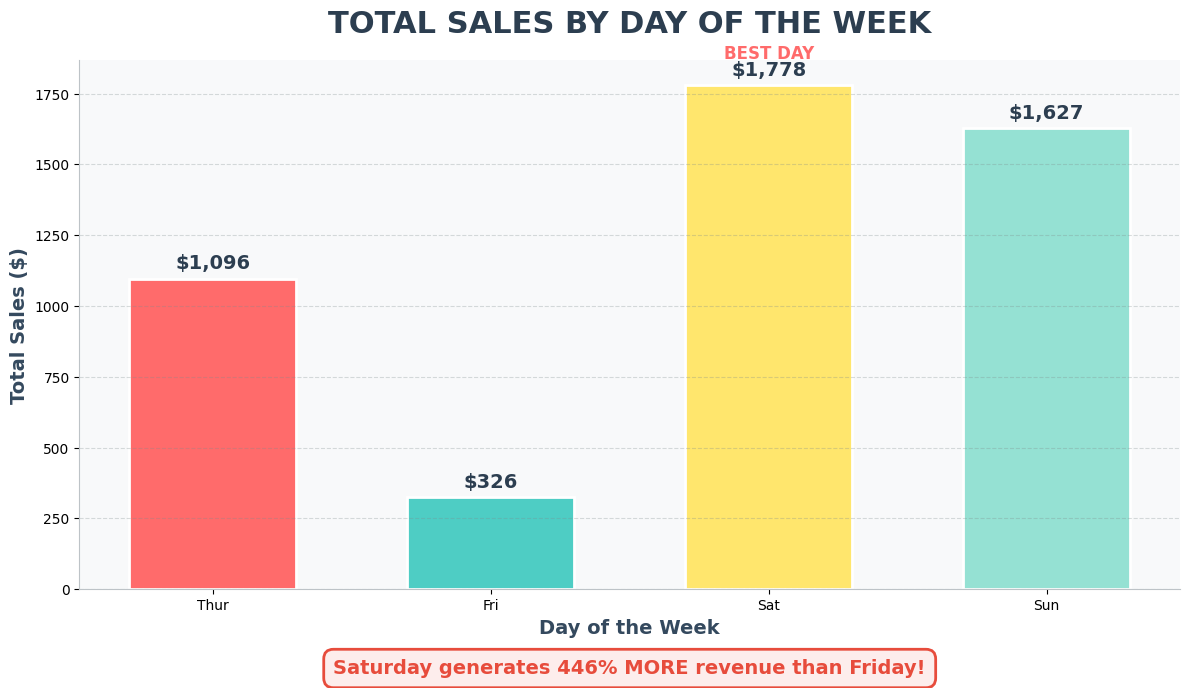

In [24]:
# ==========================================
# 6. DRAW THE LINKEDIN-WORTHY BAR CHART (NEW)
# ==========================================

# Define day order (Thursday to Sunday, as per the dataset)
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
daily_sales = daily_sales.reindex(day_order)

# Create the figure with a larger size
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the bars with gradient colors
bars = ax.bar(daily_sales.index, daily_sales.values,
              color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3'],
              edgecolor='white',
              linewidth=2,
              width=0.6)

# Add value labels on top of each bar
for bar, value in zip(bars, daily_sales.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'${value:,.0f}',
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold',
            color='#2C3E50')

# Add a "Star" on the highest bar (Saturday)
highest_day = daily_sales.idxmax()
highest_value = daily_sales.max()
for bar, day in zip(bars, daily_sales.index):
    if day == highest_day:
        ax.text(bar.get_x() + bar.get_width()/2., highest_value + 80,
                'BEST DAY',
                ha='center',
                va='bottom',
                fontsize=12,
                fontweight='bold',
                color='#FF6B6B')

# Customize the chart with a clean, professional look
ax.set_title('TOTAL SALES BY DAY OF THE WEEK',
             fontsize=22,
             fontweight='bold',
             color='#2C3E50',
             pad=20)
ax.set_xlabel('Day of the Week', fontsize=14, fontweight='bold', color='#34495E')
ax.set_ylabel('Total Sales ($)', fontsize=14, fontweight='bold', color='#34495E')

# Add a subtle grid
ax.grid(axis='y', linestyle='--', alpha=0.3, color='#7F8C8D')

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

# Add a subtle background color
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#FFFFFF')

# Add an annotation box with the key insight
insight_text = f'Saturday generates {round((highest_value - daily_sales.min()) / daily_sales.min() * 100)}% MORE revenue than Friday!'
ax.text(0.5, -0.15, insight_text,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        color='#E74C3C',
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='#FDEDEC', edgecolor='#E74C3C', linewidth=2))

# Adjust layout to prevent clipping
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('retail_sales_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')

# Display the chart
plt.show()

In [23]:
# ==========================================
# 7. FIND THE BEST DAY (KEEP THIS AS IS)
# ==========================================

best_day = daily_sales.idxmax()
best_sales = daily_sales.max()
worst_day = daily_sales.idxmin()
worst_sales = daily_sales.min()
difference = ((best_sales - worst_sales) / worst_sales) * 100

print("\n" + "="*50)
print("BUSINESS INSIGHT:")
print(f"Best day: {best_day} with ${best_sales:,.2f}")
print(f"Worst day: {worst_day} with ${worst_sales:,.2f}")
print(f"{best_day} is {difference:.0f}% HIGHER than {worst_day}")
print("="*50)


BUSINESS INSIGHT:
Best day: Sat with $1,778.40
Worst day: Fri with $325.88
Sat is 446% HIGHER than Fri
